In [45]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

In [46]:
books = pd.read_csv('Books.csv', encoding='latin-1', on_bad_lines='skip', low_memory=False)
ratings = pd.read_csv('Ratings.csv', encoding='latin-1', on_bad_lines='skip', low_memory=False)
users = pd.read_csv('Users.csv', encoding='latin-1', on_bad_lines='skip', low_memory=False)

In [47]:

books.columns = books.columns.str.strip().str.lower().str.replace('-', '_')
ratings.columns = ratings.columns.str.strip().str.lower().str.replace('-', '_')

print("Books columns:", books.columns.tolist())
print("Ratings columns:", ratings.columns.tolist())

Books columns: ['isbn', 'book_title', 'book_author', 'year_of_publication', 'publisher', 'image_url_s', 'image_url_m', 'image_url_l']
Ratings columns: ['user_id', 'isbn', 'book_rating']


In [48]:
df = ratings.merge(books, on='isbn')

In [49]:
user_counts = df['user_id'].value_counts()
active_users = user_counts[user_counts >= 50].index
df_filtered = df[df['user_id'].isin(active_users)]

In [50]:
book_counts = df_filtered['book_title'].value_counts()
popular_books = book_counts[book_counts >= 20].index
df_filtered = df_filtered[df_filtered['book_title'].isin(popular_books)]

In [51]:
print(f"Dataset shape after filtering: {df_filtered.shape}")

Dataset shape after filtering: (237110, 10)


In [52]:
pivot_matrix = df_filtered.pivot_table(index='book_title', columns='user_id', values='book_rating').fillna(0)

In [53]:
sparse_matrix = csr_matrix(pivot_matrix.values)

In [54]:
knn_model = NearestNeighbors(metric='cosine', algorithm='brute')
knn_model.fit(sparse_matrix)

,n_neighbors,5
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


In [55]:
print("KNN Model successfully trained!")

KNN Model successfully trained!


In [56]:
def recommend_collaborative(book_title, top_n=5):
    if book_title not in pivot_matrix.index:
        return f"Sorry, '{book_title}' does not have enough rating data."

    
    book_idx = pivot_matrix.index.get_loc(book_title)

    
    distances, indices = knn_model.kneighbors(
        pivot_matrix.iloc[book_idx, :].values.reshape(1, -1),
        n_neighbors=top_n + 1,
    )

   
    recommendations = []
    for i in range(1, len(distances.flatten())):
        rec_title = pivot_matrix.index[indices.flatten()[i]]
        distance = distances.flatten()[i]
        similarity = round(1 - distance, 4)

        recommendations.append(
            {"book_title": rec_title, "similarity_score": similarity}
        )

    return pd.DataFrame(recommendations)

In [57]:
sample_title = pivot_matrix.index[0]

print(f"Generating Collaborative Filtering recommendations for: '{sample_title}'\n")
recommend_collaborative(sample_title, top_n=5)

Generating Collaborative Filtering recommendations for: ''Salem's Lot'



,book_title,similarity_score
0,The Matarese Circle,0.3875
1,The Nitpicker's Guide for Next Generation Trek...,0.3250
2,The Shining,0.3034
3,Scarlatti Inheritance,0.2819
4,"Startide Rising (The Uplift Saga, Book 2)",0.2740


In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\tanju\AppData\Local\Temp\ipykernel_7208\3018970599.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="book_author",palette = 'Paired', data=books,order=books['book_author'].value_counts().index[0:20])


Text(0.5, 1.0, 'Top 20 author with number of books')

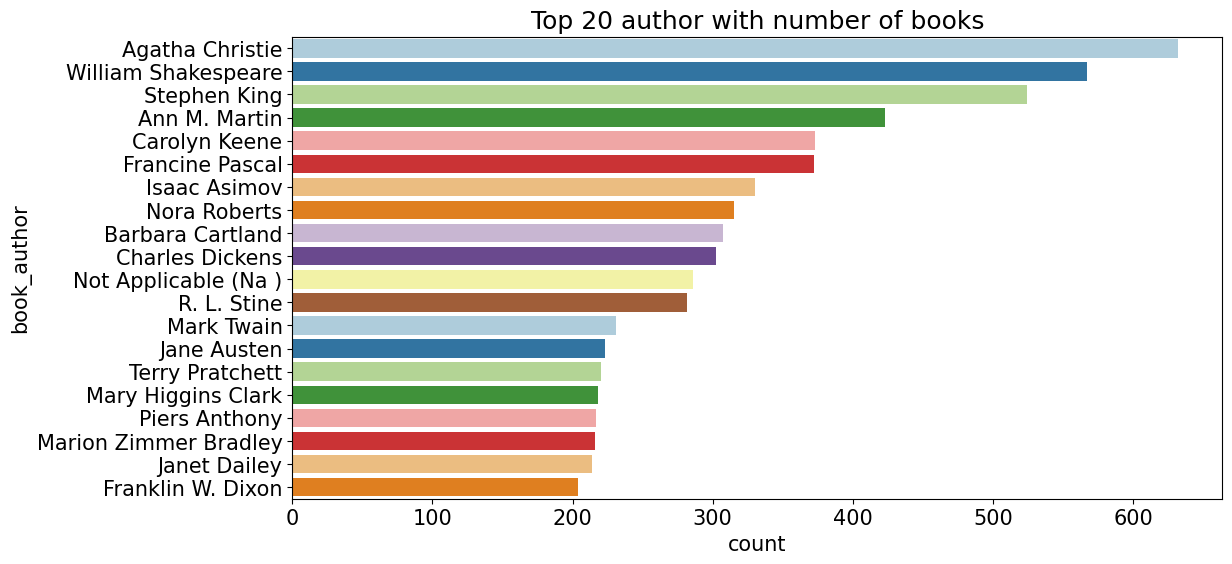

In [59]:
plt.figure(figsize=(12,6))
sns.countplot(y="book_author",palette = 'Paired', data=books,order=books['book_author'].value_counts().index[0:20])
plt.title("Top 20 author with number of books")

C:\Users\tanju\AppData\Local\Temp\ipykernel_7208\616272310.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="publisher",palette = 'Paired', data=books,order=books['publisher'].value_counts().index[0:20])


Text(0.5, 1.0, 'Top 20 Publishers with number of books published')

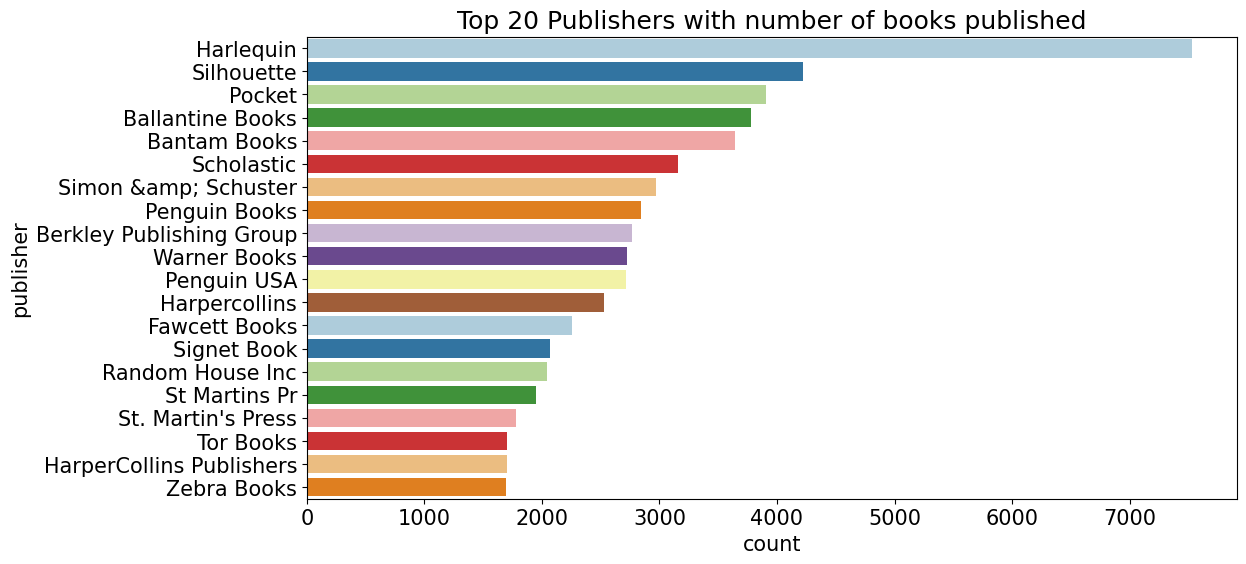

In [60]:
plt.figure(figsize=(12,6))
sns.countplot(y="publisher",palette = 'Paired', data=books,order=books['publisher'].value_counts().index[0:20])
plt.title("Top 20 Publishers with number of books published")

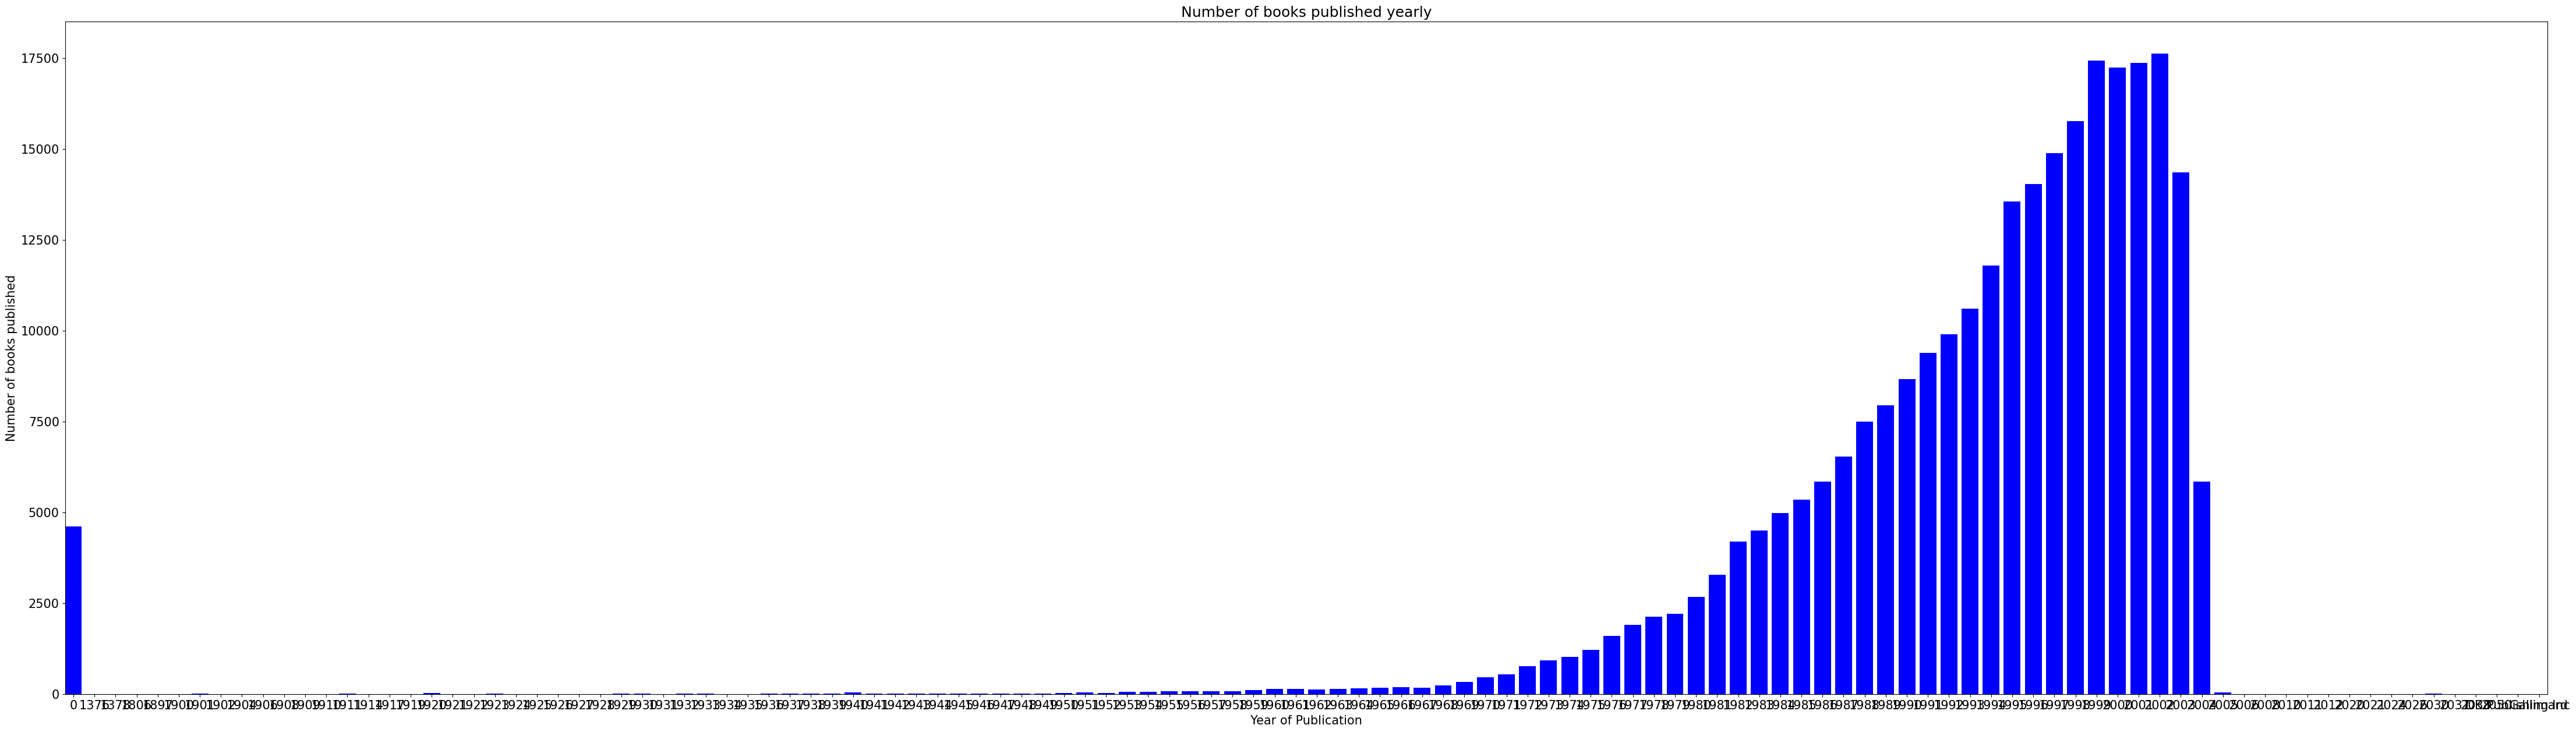

In [61]:
publications = {}
for year in books['year_of_publication']:
    if str(year) not in publications:
        publications[str(year)] = 0
    publications[str(year)] +=1

publications = {k:v for k, v in sorted(publications.items())}

fig = plt.figure(figsize =(55, 15))
plt.bar(list(publications.keys()),list(publications.values()), color = 'blue')
plt.ylabel("Number of books published")
plt.xlabel("Year of Publication")
plt.title("Number of books published yearly")
plt.margins(x = 0)
plt.show()

In [62]:
books.year_of_publication = pd.to_numeric(books.year_of_publication, errors='coerce')

# Checking for 0's or NaNs in Year of Publication
zero_year = books[books.year_of_publication == 0].year_of_publication.count()
nan_year = books.year_of_publication.isnull().sum()

print(f'There are {zero_year} entries as \'0\', and {nan_year} NaN entries in the Year of Publication field')

# Replace all years of zero with NaN
books.year_of_publication.replace(0, np.nan, inplace=True)

There are 4618 entries as '0', and 3 NaN entries in the Year of Publication field


C:\Users\tanju\AppData\Local\Temp\ipykernel_7208\44544725.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  books.year_of_publication.replace(0, np.nan, inplace=True)


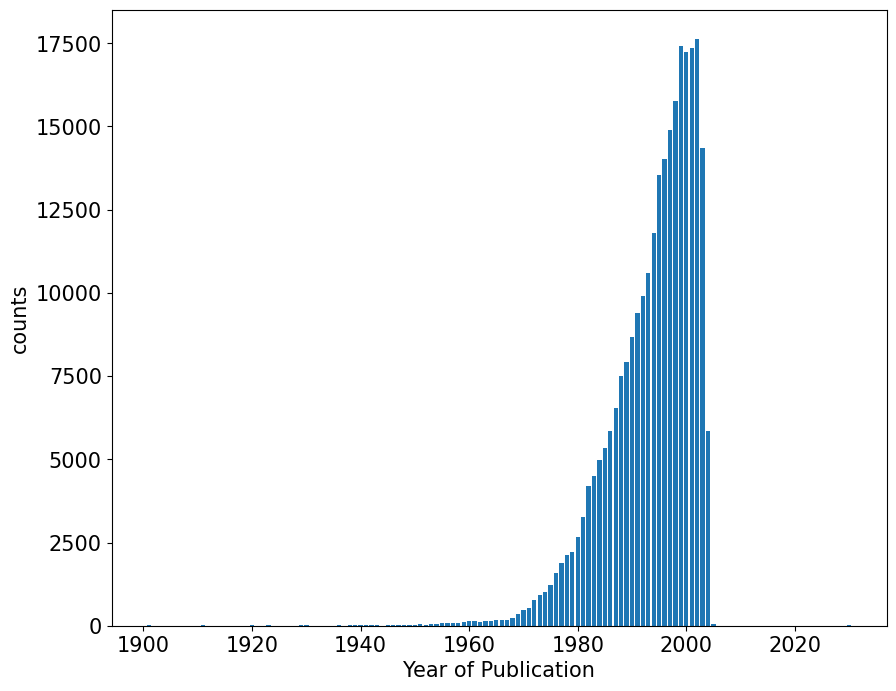

In [63]:
year = books.year_of_publication.value_counts().sort_index()
year = year.where(year>5) 
plt.figure(figsize=(10, 8))
plt.rcParams.update({'font.size': 15}) 
plt.bar(year.index, year.values)
plt.xlabel('Year of Publication')
plt.ylabel('counts')
plt.show()

C:\Users\tanju\AppData\Local\Temp\ipykernel_7208\3792902813.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="book_title",palette = 'Paired',data= books, order=books['book_title'].value_counts().index[0:15])


Text(0.5, 1.0, 'Top 20 books as per number of ratings')

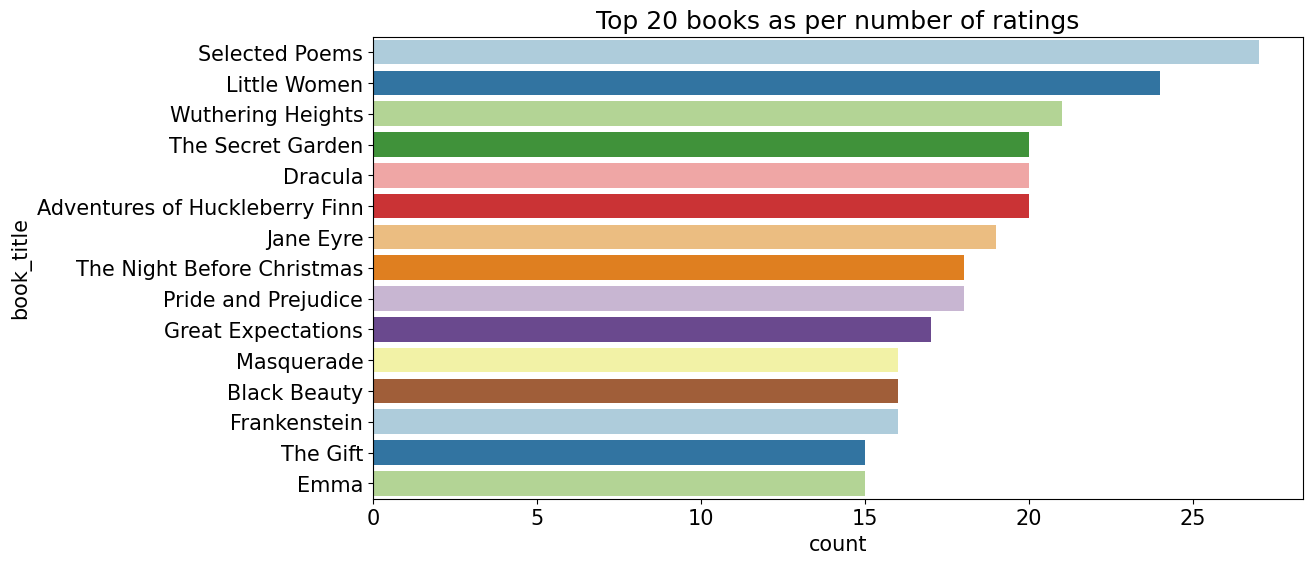

In [65]:
plt.figure(figsize=(12,6))
sns.countplot(y="book_title",palette = 'Paired',data= books, order=books['book_title'].value_counts().index[0:15])
plt.title("Top 20 books as per number of ratings")